In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Washed-out Image')

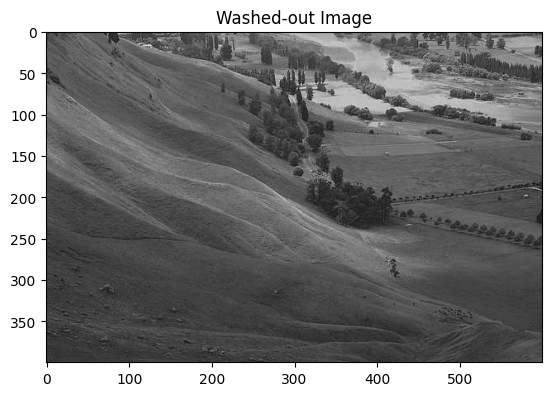

In [2]:
washout=cv2.imread("../test_assets/histogram.jpg",0)

plt.imshow(washout, cmap="gray")
plt.title("Washed-out Image")

In [3]:
# Using the calcHist and LUT is must
def histogram_equalization(image):
    M,N=image.shape
    total_pixels = M*N
    L=256
    # histogram = np.zeros(L, dtype=np.int32)
    # for i in range(M):
    #     for j in range(N):
    #         pixel_intensity=image[i,j]
    #         histogram[pixel_intensity] += 1
    histogram=cv2.calcHist([image], [0], None, [256], [0,256]).flatten()

    probability=np.zeros(L, dtype=np.float32)
    for i in range(L):
        probability[i] = histogram[i]/total_pixels
    
    cumulative_sum_array=np.zeros(L, dtype=np.float32)
    transformation_fn=np.zeros(L, dtype=np.int32)
    for i in range(L):
        cumulative_sum=0.0
        for j in range(i+1):
            cumulative_sum += probability[j]
        cumulative_sum_array[i] = cumulative_sum
        transformation_fn[i] = round((L-1)*cumulative_sum)
        if transformation_fn[i]>255:
            transformation_fn[i]=255

    equalized_image=np.zeros_like(image)
    # for i in range(M):
    #     for j in range(N):
    #         old_value=image[i,j]
    #         new_value=transformation_fn[old_value]
    #         equalized_image[i,j]=new_value
    equalized_image = cv2.LUT(image, transformation_fn.astype(np.uint8))

    return histogram, probability, cumulative_sum_array, transformation_fn, equalized_image


In [4]:
hist,prob,cum_sum_arr,tx_fn,equ_img= histogram_equalization(washout)

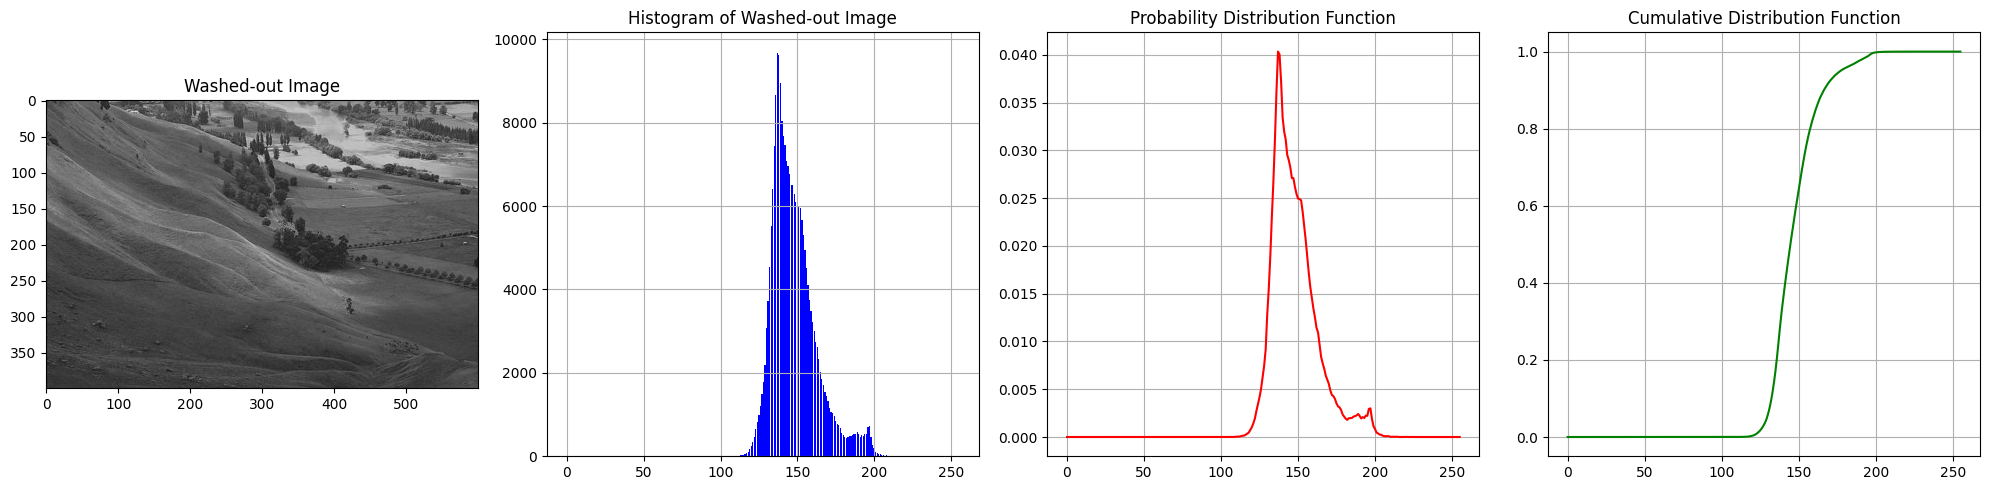

In [5]:
plt.figure(figsize=(20,5))
plt.subplot(1,4,1)
plt.imshow(washout, cmap="gray")
plt.title("Washed-out Image")

plt.subplot(1,4,2)
plt.bar(range(256), hist, color='blue')
plt.title("Histogram of Washed-out Image")
plt.grid(True)

plt.subplot(1,4,3)
plt.plot(range(256), prob, color='red')
plt.title("Probability Distribution Function")
plt.grid(True)

plt.subplot(1,4,4)
plt.plot(range(256), cum_sum_arr, color='green')
plt.title("Cumulative Distribution Function")
plt.grid(True)

plt.tight_layout()
plt.show()

In [6]:
hist2,prob2,cum_sum_arr2,tx_fn2,equ_img2= histogram_equalization(equ_img)

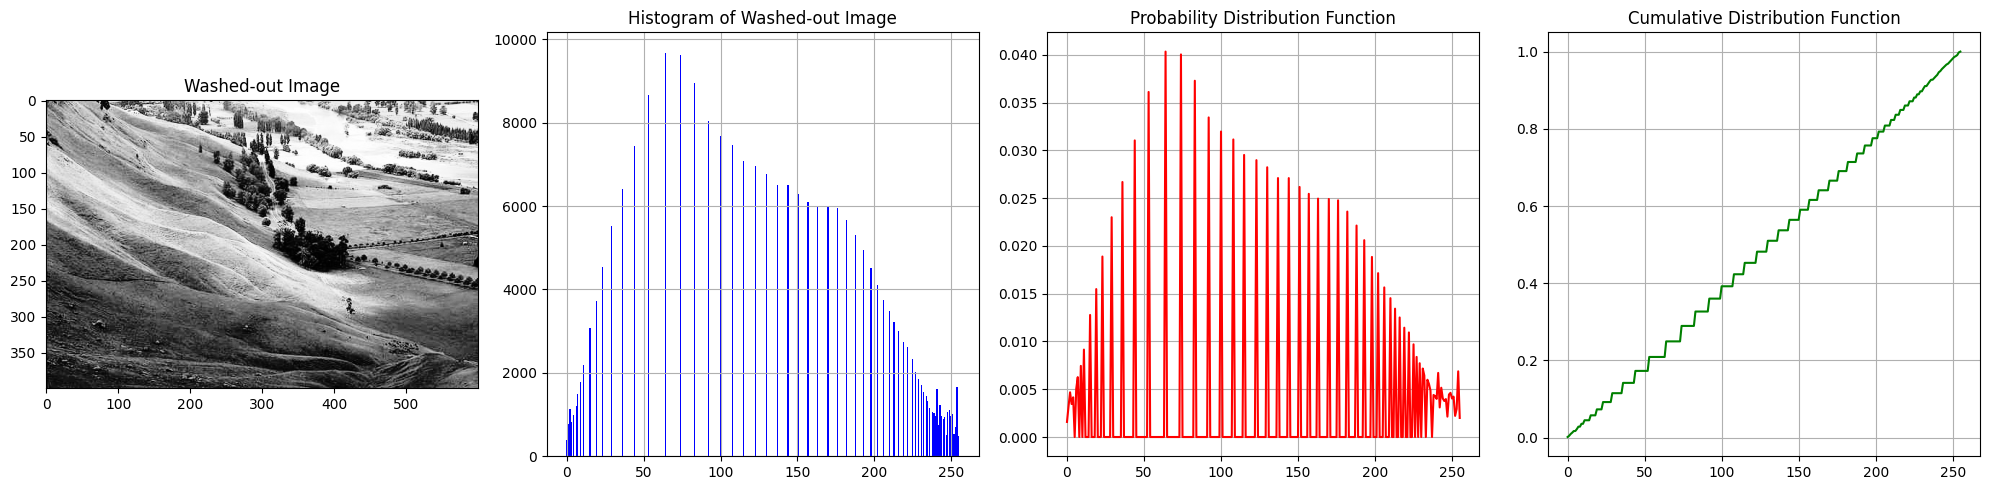

In [7]:
plt.figure(figsize=(20,5))
plt.subplot(1,4,1)
plt.imshow(equ_img, cmap="gray")
plt.title("Washed-out Image")

plt.subplot(1,4,2)
plt.bar(range(256), hist2, color='blue')
plt.title("Histogram of Washed-out Image")
plt.grid(True)

plt.subplot(1,4,3)
plt.plot(range(256), prob2, color='red')
plt.title("Probability Distribution Function")
plt.grid(True)

plt.subplot(1,4,4)
plt.plot(range(256), cum_sum_arr2, color='green')
plt.title("Cumulative Distribution Function")
plt.grid(True)

plt.tight_layout()
plt.show()

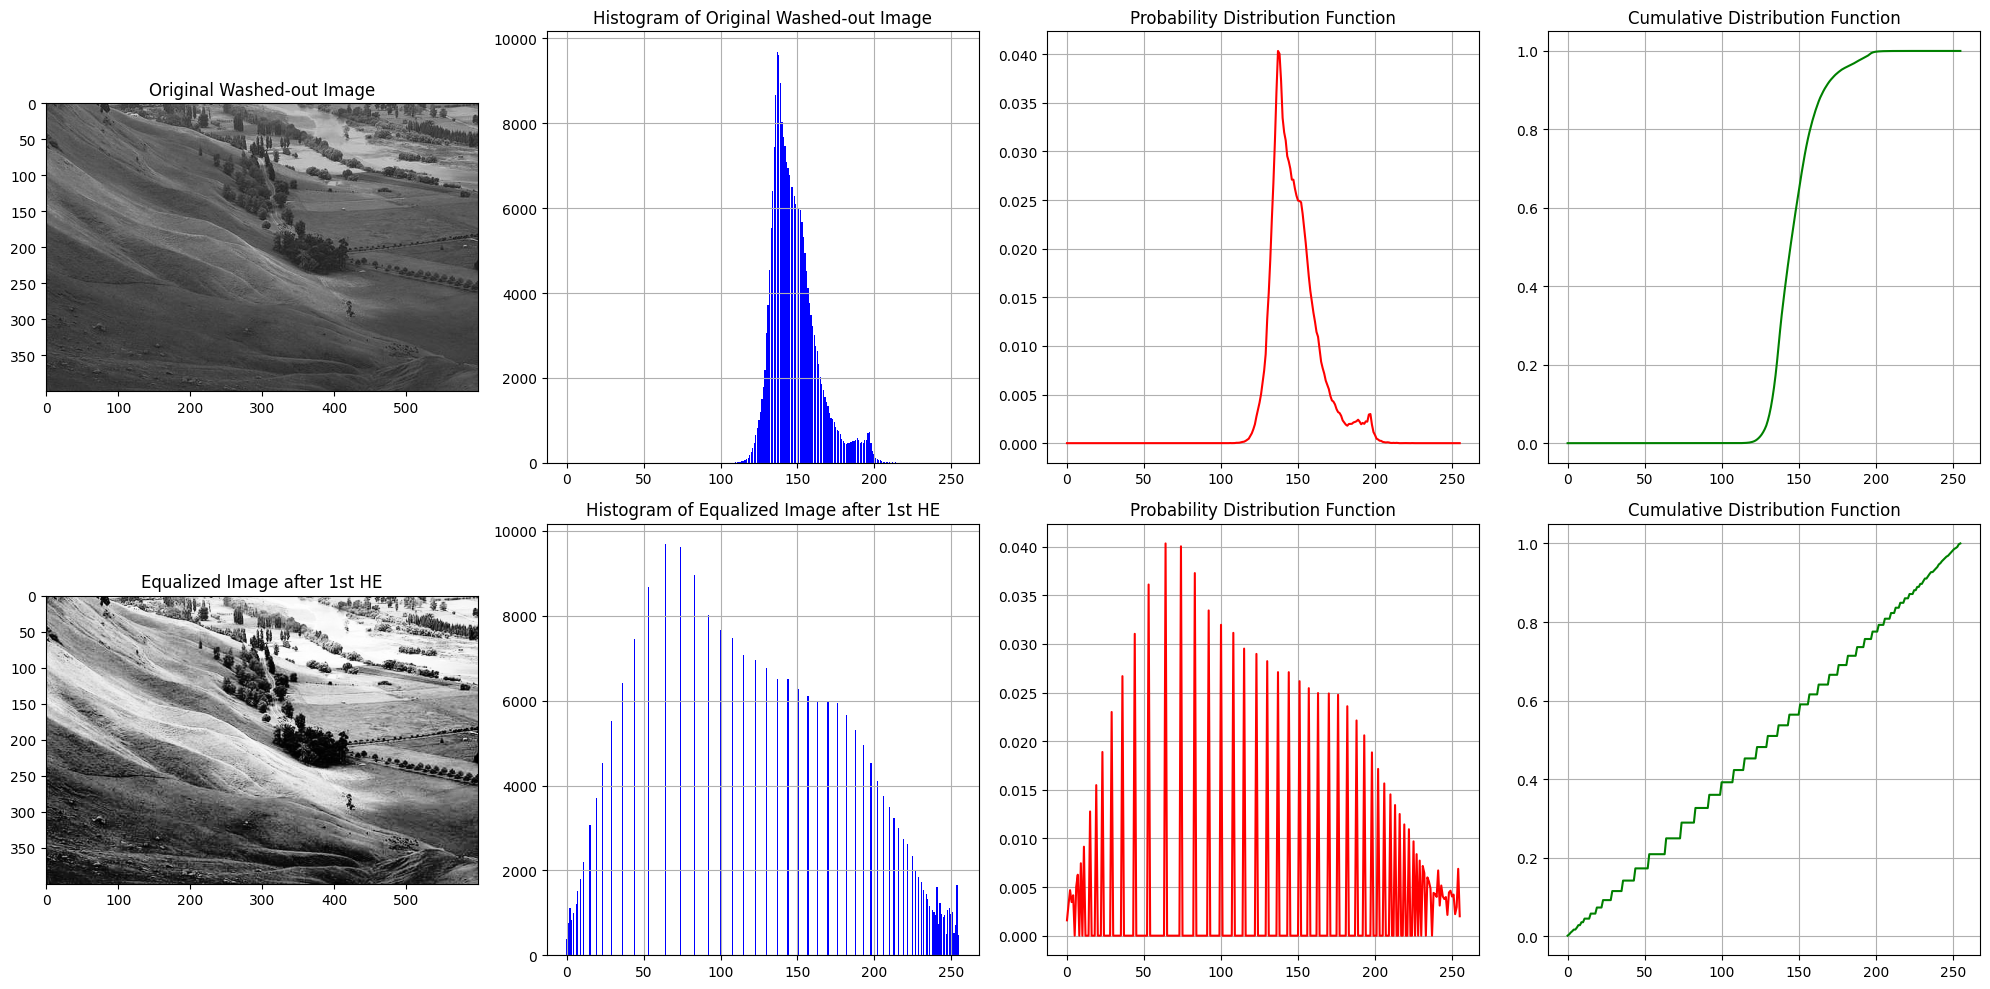

In [8]:
plt.figure(figsize=(20,10))

plt.subplot(2,4,1)
plt.imshow(washout, cmap="gray")
plt.title("Original Washed-out Image")

plt.subplot(2,4,2)
plt.bar(range(256), hist, color='blue')
plt.title("Histogram of Original Washed-out Image")
plt.grid(True)

plt.subplot(2,4,3)
plt.plot(range(256), prob, color='red')
plt.title("Probability Distribution Function")
plt.grid(True)

plt.subplot(2,4,4)
plt.plot(range(256), cum_sum_arr, color='green')
plt.title("Cumulative Distribution Function")
plt.grid(True)

plt.subplot(2,4,5)
plt.imshow(equ_img, cmap="gray")
plt.title("Equalized Image after 1st HE")

plt.subplot(2,4,6)
plt.bar(range(256), hist2, color='blue')
plt.title("Histogram of Equalized Image after 1st HE")
plt.grid(True)

plt.subplot(2,4,7)
plt.plot(range(256), prob2, color='red')
plt.title("Probability Distribution Function")
plt.grid(True)

plt.subplot(2,4,8)
plt.plot(range(256), cum_sum_arr2, color='green')
plt.title("Cumulative Distribution Function")
plt.grid(True)

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Original Color Image in HSV')

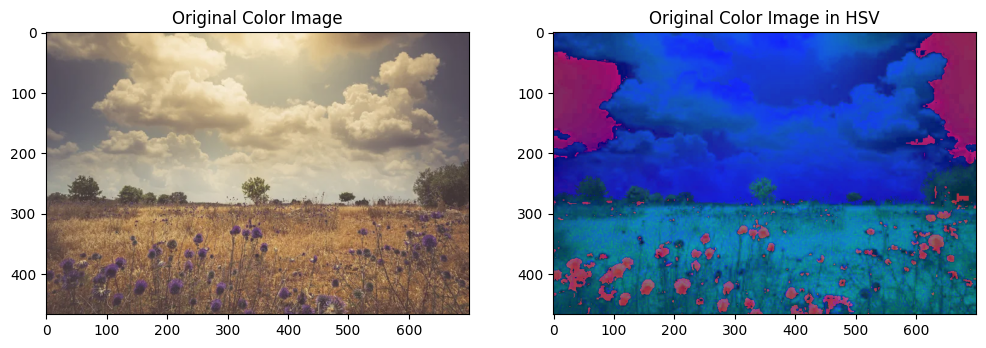

In [9]:
col=cv2.imread("../test_assets/col.jpg",1)
col2=cv2.cvtColor(col, cv2.COLOR_BGR2HSV)

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(col, cv2.COLOR_BGR2RGB))
plt.title("Original Color Image")

plt.subplot(1,2,2)
plt.imshow(col2, cmap="hsv")
plt.title("Original Color Image in HSV")

In [10]:
b,g,r=cv2.split(col)

In [11]:
histb,probb,cum_sum_arrb,tx_fnb,equ_imgb= histogram_equalization(b)
histb,probg,cum_sum_arrg,tx_fnr,equ_imgg= histogram_equalization(g)
histr,probr,cum_sum_arrr,tx_fnr,equ_imgr= histogram_equalization(r)

In [12]:
merged=cv2.merge([equ_imgb, equ_imgg, equ_imgr])

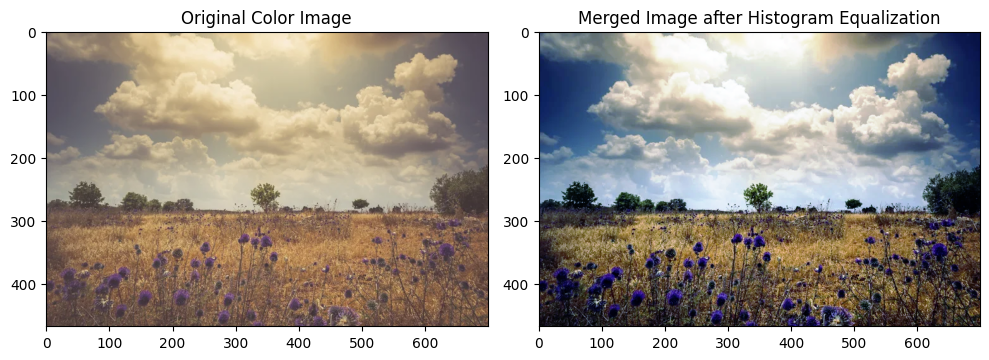

In [13]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(col, cv2.COLOR_BGR2RGB))
plt.title("Original Color Image")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(merged, cv2.COLOR_BGR2RGB))
plt.title("Merged Image after Histogram Equalization")

plt.tight_layout()
plt.show()

In [14]:
h,s,v=cv2.split(col2)

In [15]:
histv,probv,cum_sum_arrv,tx_fnv,equ_imgv= histogram_equalization(v)

merged_hsv=cv2.merge([h, s, equ_imgv])

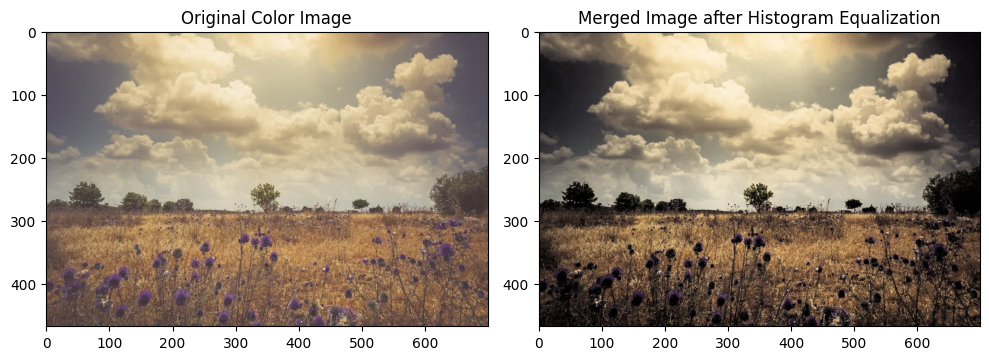

In [16]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(col, cv2.COLOR_BGR2RGB))
plt.title("Original Color Image")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(merged_hsv, cv2.COLOR_HSV2RGB))
plt.title("Merged Image after Histogram Equalization")

plt.tight_layout()
plt.show()